# Visualización de datos

### Importación de librerías

In [22]:
#importamos las librerías necesarias para hacer nuestras graficas
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

### Carga de datos

In [23]:
#cargamos los datos y los hacemos un dataframe
df_biare = pd.read_csv("../Limpieza de datos (Practica 1)/biare_limpio_2021_2024.csv")

#debido a que el csv no guarda e tipo de dato, nosotros se lo damos
df_biare['N_ENT'] = df_biare['N_ENT'].astype(str)
df_biare['N_REN'] = df_biare['N_REN'].astype(str)

# Gráficas descriptivas

#### Histogramas sobre las preguntas de satisfacción con la vida en general

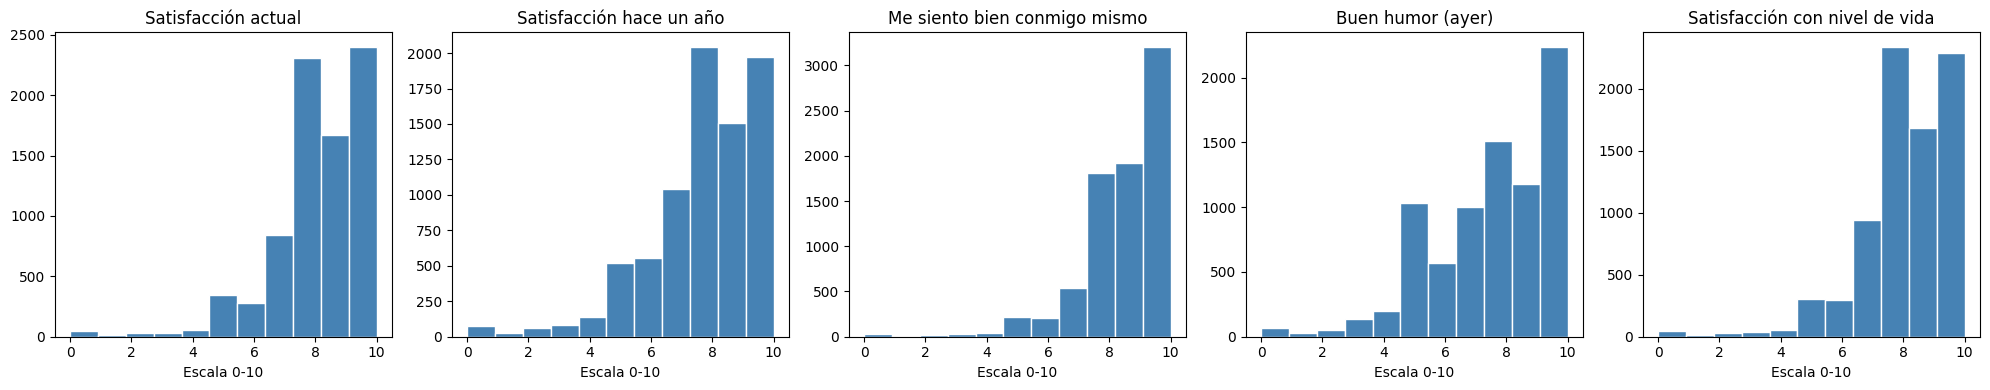

In [24]:
preguntas = ['cb_P1', 'cb_P2', 'cb_P3_1', 'cb_P4_1', 'cb_P5_1']
titulos = ['Satisfacción actual', 'Satisfacción hace un año',
           'Me siento bien conmigo mismo', 'Buen humor (ayer)', 'Satisfacción con nivel de vida']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for ax, pregunta, titulo in zip(axes, preguntas, titulos):
    ax.hist(df_biare[pregunta].dropna(), bins=11, color='steelblue', edgecolor='white')
    ax.set_title(titulo)
    ax.set_xlabel('Escala 0-10')

plt.tight_layout()
plt.show()

#### box plot de satisfacción con la vida por año

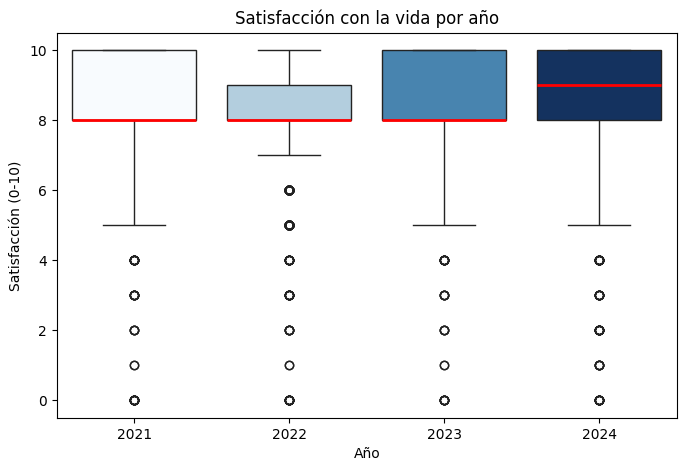

In [25]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_biare, x='ANIO', y='cb_P1', hue='ANIO', palette='Blues', legend=False,
            medianprops={'color': 'red', 'linewidth': 2})
plt.title('Satisfacción con la vida por año')
plt.xlabel('Año')
plt.ylabel('Satisfacción (0-10)')
plt.show()

#### Heatmap en comparación de la satisfaccióm con la vida y la edad

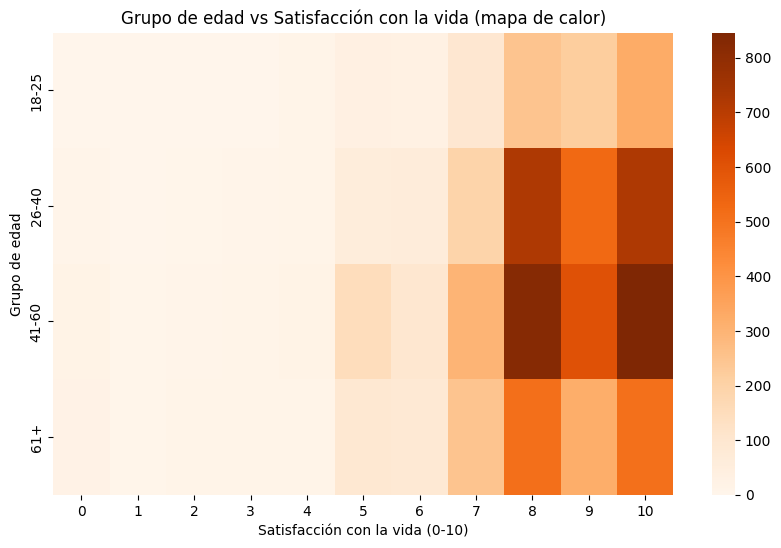

In [26]:
df_biare['grupo_edad'] = pd.cut(df_biare['cs_EDA'],
                                  bins=[0, 25, 40, 60, 100],
                                  labels=['18-25', '26-40', '41-60', '61+'])

plt.figure(figsize=(10, 6))
tabla_cruzada_edad = pd.crosstab(df_biare['grupo_edad'], df_biare['cb_P1'])
sns.heatmap(tabla_cruzada_edad, cmap='Oranges', annot=False)
plt.title('Grupo de edad vs Satisfacción con la vida (mapa de calor)')
plt.xlabel('Satisfacción con la vida (0-10)')
plt.ylabel('Grupo de edad')
plt.show()

#### Pie chart sobre la distribución de edades en la muestra

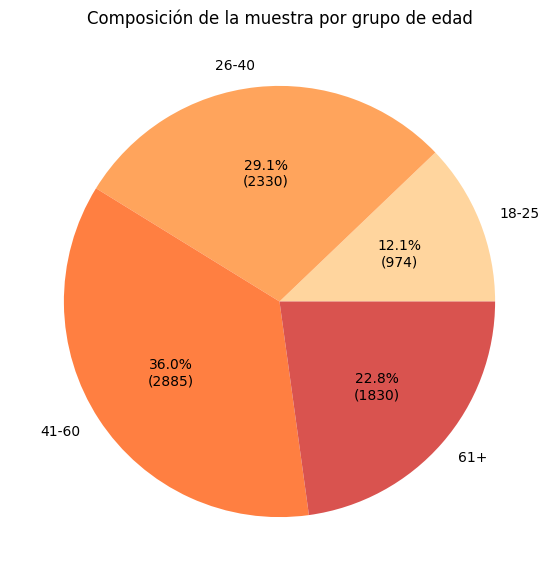

In [27]:
conteo_edad = df_biare['grupo_edad'].value_counts().sort_index()
total = conteo_edad.sum()

def mostrar_pct_y_cantidad(pct):
    cantidad = int(round(pct / 100 * total))
    return f'{pct:.1f}%\n({cantidad})'

plt.figure(figsize=(7, 7))
plt.pie(conteo_edad, labels=conteo_edad.index, autopct=mostrar_pct_y_cantidad,
        colors=['#FFD59E', '#FFA45C', '#FF7F41', '#D9534F'])
plt.title('Composición de la muestra por grupo de edad')
plt.show()

#### Pie chart sobre la distribución de géneros en la muestra

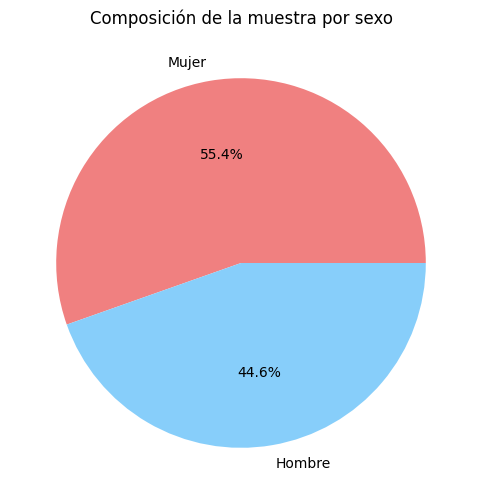

In [28]:
conteo_sexo = df_biare['cs_SEX'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(conteo_sexo, labels=conteo_sexo.index, autopct='%1.1f%%', colors=['lightcoral', 'lightskyblue'])
plt.title('Composición de la muestra por sexo')
plt.show()

#### Gráfico de barras con el promedio de satisfacción con la vida por estado

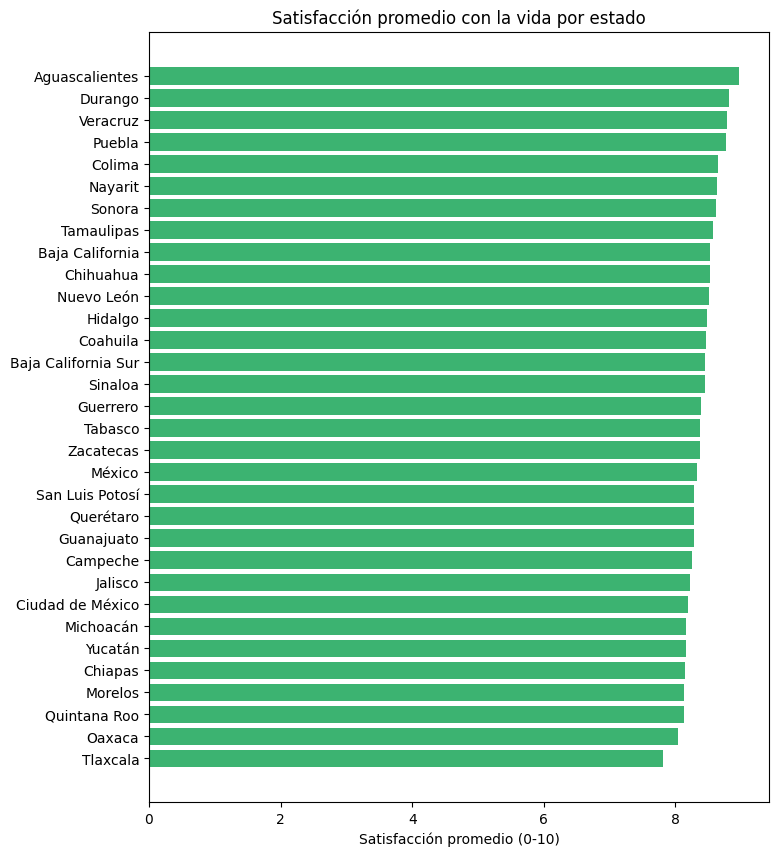

In [29]:
promedio_estado = df_biare.groupby('ENT')['cb_P1'].mean().sort_values()

plt.figure(figsize=(8, 10))
plt.barh(promedio_estado.index, promedio_estado.values, color='mediumseagreen')
plt.title('Satisfacción promedio con la vida por estado')
plt.xlabel('Satisfacción promedio (0-10)')
plt.show()

#### Boxplot de satisfacción con la vida por nivel económico

/var/folders/hx/39srdrds5_363qz26gc146440000gn/T/ipykernel_87187/4018382302.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_biare, x='nivel_economico', y='cb_P1',


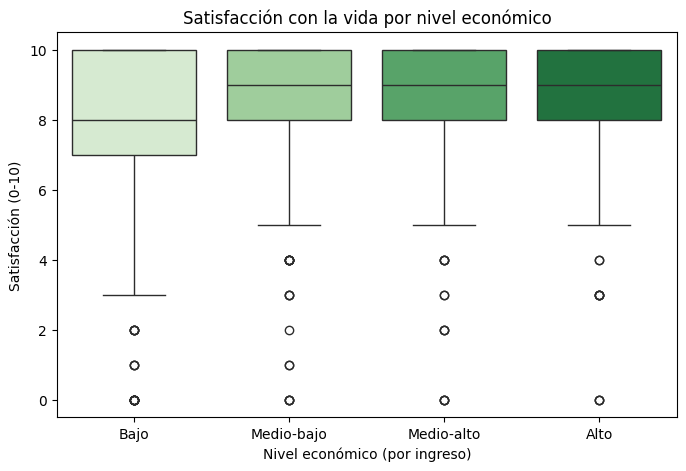

In [30]:
# Creamos rangos de ingreso usando cuartiles (4 grupos con cantidad similar de personas en cada uno)
df_biare['nivel_economico'] = pd.qcut(df_biare['cs_ING'], q=4,
                                        labels=['Bajo', 'Medio-bajo', 'Medio-alto', 'Alto'])

plt.figure(figsize=(8, 5))
sns.boxplot(data=df_biare, x='nivel_economico', y='cb_P1',
            order=['Bajo', 'Medio-bajo', 'Medio-alto', 'Alto'], palette='Greens')
plt.title('Satisfacción con la vida por nivel económico')
plt.xlabel('Nivel económico (por ingreso)')
plt.ylabel('Satisfacción (0-10)')
plt.show()

##### Histogramas sobre las preguntas de la satisfacción con dominions especificos 

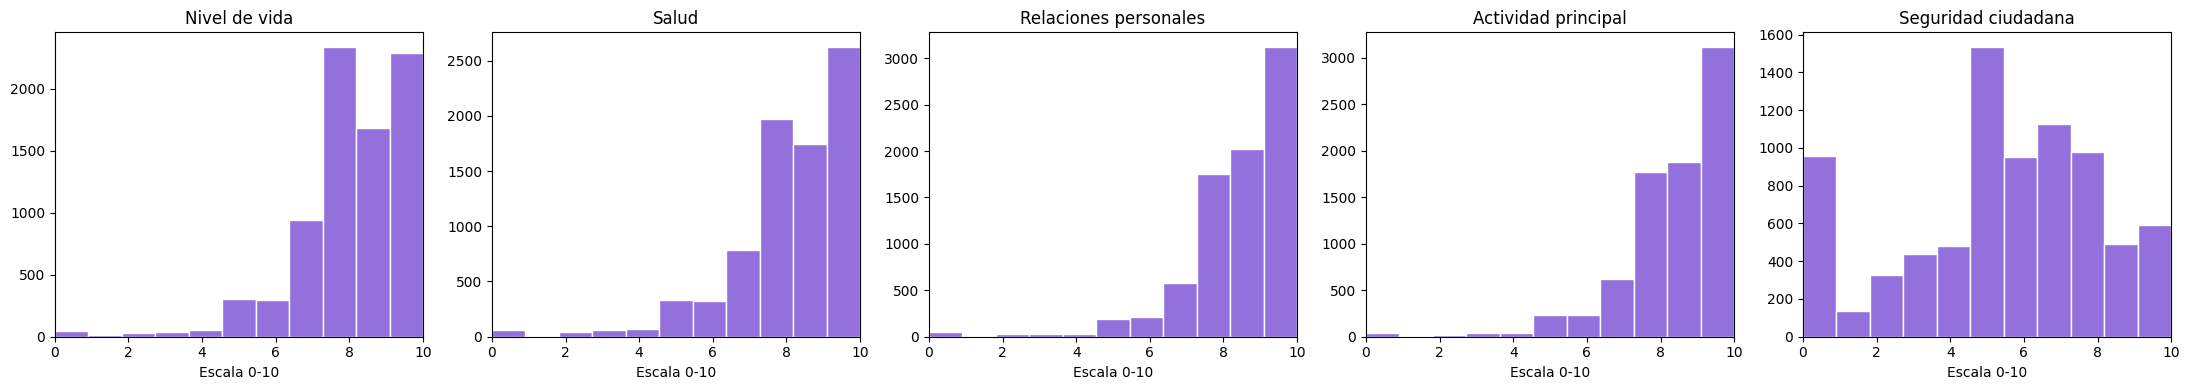

In [31]:
dominios = ['cb_P5_1', 'cb_P5_2', 'cb_P5_4', 'cb_P5_8', 'cb_P5_7']
titulos = ['Nivel de vida', 'Salud', 'Relaciones personales',
           'Actividad principal', 'Seguridad ciudadana']

fig, axes = plt.subplots(1, 5, figsize=(22, 4))

for ax, dominio, titulo in zip(axes, dominios, titulos):
    ax.hist(df_biare[dominio].dropna(), bins=11, color='mediumpurple', edgecolor='white')
    ax.set_title(titulo)
    ax.set_xlabel('Escala 0-10')
    ax.set_xlim(0, 10)

plt.tight_layout()
plt.show()

##### Heatmap con la comparación entre la seguridad ciudadana y la satisfacción con la vida

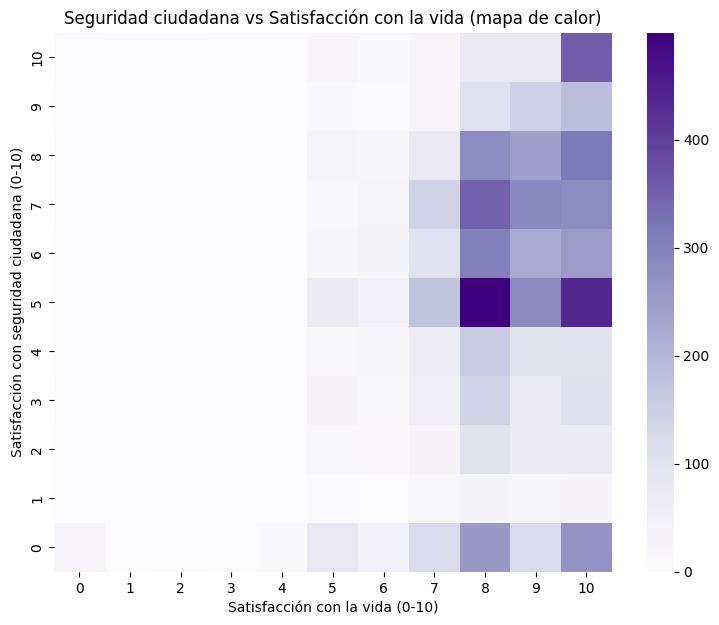

In [32]:
import numpy as np

tabla_cruzada = pd.crosstab(df_biare['cb_P5_7'], df_biare['cb_P1'])

plt.figure(figsize=(9, 7))
sns.heatmap(tabla_cruzada, cmap='Purples', annot=False)
plt.title('Seguridad ciudadana vs Satisfacción con la vida (mapa de calor)')
plt.xlabel('Satisfacción con la vida (0-10)')
plt.ylabel('Satisfacción con seguridad ciudadana (0-10)')
plt.gca().invert_yaxis()
plt.show()